# 인구 대비 Olist 이용량과 물류 인프라 투자 후보 분석

이 노트북의 목적은 만족도 자체를 올리는 것이 아니라, **물류 인프라 구축 필요 지역을 찾는 것**입니다.

따라서 분석 질문은 다음과 같습니다.

1. 주별/권역별 인구 규모 대비 Olist 이용량은 어느 정도인가?
2. 인구 대비 이용량이 낮은 지역에서 배송 지연, 배송 소요 시간, 평점 저하가 함께 나타나는가?
3. 인프라 투자를 통해 이용량 확대와 배송 경험 개선을 동시에 기대할 수 있는 지역은 어디인가?

분석 기준은 고객 도착지입니다. 리뷰와 구매 경험은 고객이 체감하는 것이므로 `customer_state`, `customer_region` 기준으로 집계합니다.

## 1. 라이브러리와 데이터 경로

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

def move_usage_rate_columns_after_items(df):
    usage_cols = ["orders_per_100k", "customers_per_100k", "items_per_100k"]
    if "items" not in df.columns:
        return df
    existing_usage_cols = [col for col in usage_cols if col in df.columns]
    remaining_cols = [col for col in df.columns if col not in existing_usage_cols]
    insert_at = remaining_cols.index("items") + 1
    ordered_cols = remaining_cols[:insert_at] + existing_usage_cols + remaining_cols[insert_at:]
    return df[ordered_cols]

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

ORDER_DATA_PATH = ROOT / "data" / "processed" / "olist_delivered_item_level_cleaned_errors.csv"
POPULATION_PATH = ROOT / "data" / "brazil_state_population_2016_2018.csv"
OUTPUT_DIR = ROOT / "notebooks" / "Distribution_hub" / "SG" / "Logistics_folder" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORDER_DATA_PATH, POPULATION_PATH

(WindowsPath('c:/team-oldest-olist-analysis/data/processed/olist_delivered_item_level_cleaned_errors.csv'),
 WindowsPath('c:/team-oldest-olist-analysis/data/brazil_state_population_2016_2018.csv'))

## 2. 데이터 로드

주문 데이터는 배송 완료 및 오류 보정이 끝난 item-level 데이터를 사용합니다. 인구 데이터는 별도 CSV를 사용하되, 권역명은 전처리 데이터의 `customer_region` 값과 일치하도록 만들어둔 파일을 사용합니다.

In [2]:
DATE_COLS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
]

orders_raw = pd.read_csv(ORDER_DATA_PATH, parse_dates=DATE_COLS)
population_wide = pd.read_csv(POPULATION_PATH)

print(f"item-level rows: {len(orders_raw):,}")
print(f"order count: {orders_raw['order_id'].nunique():,}")
print(f"population rows: {len(population_wide):,}")

display(orders_raw.head())
display(population_wide.head())

item-level rows: 108,581
order count: 95,082
population rows: 27


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_total,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,purchase_year,purchase_month,purchase_weekday,purchase_hour,anomaly_carrier_before_approved,anomaly_customer_before_carrier,anomaly_missing_required_delivery_date,anomaly_flag,delivery_days_all,delivery_days_clean,is_late,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_state_kor,customer_region,customer_geo_lat,customer_geo_lng,customer_geo_city,customer_geo_state,seller_zip_code_prefix,seller_city,seller_state,seller_state_kor,seller_region,seller_geo_lat,seller_geo_lng,seller_geo_city,seller_geo_state,seller_state_geo_mismatch,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_value_total,payment_installments_max,payment_type_nunique,payment_types,review_score_mean,review_count,review_creation_min,review_answer_max,seller_customer_same_state,delivery_route,is_seller_geo_unreliable
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9000,13.2900,72.1900,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,2017-09-13,2017,9,Wednesday,8,False,False,False,0,7,7,False,True,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,리우데자네이루주,남동부,-21.7628,-41.3096,campos dos goytacazes,RJ,27277,volta redonda,SP,상파울루주,남동부,-22.4970,-44.1275,volta redonda,RJ,True,cool_stuff,58.0000,598.0000,4.0000,650.0000,28.0000,9.0000,14.0000,cool_stuff,72.1900,2.0000,1.0000,credit_card,5.0000,1.0000,2017-09-21 00:00:00,2017-09-22 10:57:03,False,SP -> RJ,True
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9000,19.9300,259.8300,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,2017-04-26,2017,4,Wednesday,10,False,False,False,0,16,16,False,True,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,상파울루주,남동부,-20.2205,-50.9034,santa fe do sul,SP,3471,sao paulo,SP,상파울루주,남동부,-23.5651,-46.5186,sao paulo,SP,False,pet_shop,56.0000,239.0000,2.0000,"30,000.0000",50.0000,30.0000,40.0000,pet_shop,259.8300,3.0000,1.0000,credit_card,4.0000,1.0000,2017-05-13 00:00:00,2017-05-15 11:34:13,True,SP -> SP,False
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0000,17.8700,216.8700,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,2018-01-14,2018,1,Sunday,14,False,False,False,0,7,7,False,True,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,미나스제라이스주,남동부,-19.8703,-44.5933,para de minas,MG,37564,borda da mata,MG,미나스제라이스주,남동부,-22.2626,-46.1711,borda da mata,MG,False,moveis_decoracao,59.0000,695.0000,2.0000,"3,050.0000",33.0000,13.0000,33.0000,furniture_decor,216.8700,5.0000,1.0000,credit_card,5.0000,1.0000,2018-01-23 00:00:00,2018-01-23 16:06:31,True,MG -> MG,False
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.9900,12.7900,25.7800,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2018-08-08,2018,8,Wednesday,10,False,False,False,0,6,6,False,True,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,상파울루주,남동부,-23.0899,-46.6117,atibaia,SP,14403,franca,SP,상파울루주,남동부,-20.5536,-47.3874,franca,SP,False,perfumaria,42.0000,480.0000,1.0000,200.0000,16.0000,10.0000,15.0000,perfumery,25.7800,

,region,state,uf,population_2016,population_2017,population_2018
0,북부,Rondônia,RO,1787279,1805788,1757589
1,북부,Acre,AC,816687,829619,869265
2,북부,Amazonas,AM,4001667,4063614,4080611
3,북부,Roraima,RR,514229,522636,576568
4,북부,Pará,PA,8272724,8366628,8513497


## 3. 주문 단위 분석 테이블 생성

`olist_delivered_item_level_cleaned_errors.csv`는 주문-상품 단위입니다. 인구 대비 이용량은 주문 단위로 보는 것이 자연스럽기 때문에 `order_id` 기준으로 중복을 제거한 주문 단위 테이블을 만듭니다.

다품목 주문의 상품 수는 `item_count`로 별도 저장하고, 결제액과 운임은 주문 단위 합계로 집계합니다.

In [3]:
first_cols = [
    "order_id",
    "customer_unique_id",
    "customer_state",
    "customer_region",
    "purchase_year",
    "purchase_month",
    "delivery_days_clean",
    "is_late",
    "review_score_mean",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
first_cols = [col for col in first_cols if col in orders_raw.columns]

agg_spec = {col: "first" for col in first_cols if col != "order_id"}
for col in ["freight_value", "item_total", "payment_value_total"]:
    if col in orders_raw.columns:
        agg_spec[col] = "sum"

order_df = orders_raw.groupby("order_id", as_index=False).agg(agg_spec)
order_df["item_count"] = orders_raw.groupby("order_id").size().reindex(order_df["order_id"]).to_numpy()

rename_map = {
    "freight_value": "order_freight_total",
    "item_total": "order_item_total",
    "payment_value_total": "order_payment_total",
}
order_df = order_df.rename(columns=rename_map)

order_df["delivery_vs_estimated_days"] = (
    order_df["order_delivered_customer_date"] - order_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86_400

order_df = order_df[order_df["purchase_year"].isin([2016, 2017, 2018])].copy()

print(f"order-level rows: {len(order_df):,}")
display(order_df.head())

order-level rows: 95,082


,order_id,customer_unique_id,customer_state,customer_region,purchase_year,purchase_month,delivery_days_clean,is_late,review_score_mean,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_freight_total,order_item_total,order_payment_total,item_count,delivery_vs_estimated_days
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,RJ,남동부,2017,9,7,False,5.0000,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,13.2900,72.1900,72.1900,1,-8.0113
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,SP,남동부,2017,4,16,False,4.0000,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,19.9300,259.8300,259.8300,1,-2.3303
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,MG,남동부,2018,1,7,False,5.0000,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,17.8700,216.8700,216.8700,1,-13.4450
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,SP,남동부,2018,8,6,False,4.0000,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,12.7900,25.7800,25.7800,1,-5.4357
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,SP,남동부,2017,2,25,False,5.0000,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,18.1400,218.0400,218.0400,1,-15.3038


## 4. 인구 데이터 long format 변환

2016~2018 인구 컬럼을 연도별 행 구조로 변환해서 주문 집계와 결합합니다.

In [4]:
population_long = population_wide.melt(
    id_vars=["region", "state", "uf"],
    value_vars=["population_2016", "population_2017", "population_2018"],
    var_name="year",
    value_name="population",
)
population_long["purchase_year"] = population_long["year"].str.extract(r"(\d{4})").astype(int)
population_long = population_long.drop(columns="year")

display(population_long.head())

,region,state,uf,population,purchase_year
0,북부,Rondônia,RO,1787279,2016
1,북부,Acre,AC,816687,2016
2,북부,Amazonas,AM,4001667,2016
3,북부,Roraima,RR,514229,2016
4,북부,Pará,PA,8272724,2016


## 5. 주별 인구 대비 Olist 이용량

주별 이용량은 고객 도착지 기준으로 계산합니다.

- `orders_per_100k`: 인구 10만 명당 주문 수
- `customers_per_100k`: 인구 10만 명당 고유 고객 수
- `items_per_100k`: 인구 10만 명당 주문 상품 수

이 값들이 낮으면 Olist 이용 침투율이 낮은 지역으로 볼 수 있습니다.

In [5]:
state_year_usage = (
    order_df.groupby(["purchase_year", "customer_state", "customer_region"], as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        items=("item_count", "sum"),
        avg_review_score=("review_score_mean", "mean"),
        median_delivery_days=("delivery_days_clean", "median"),
        avg_delivery_days=("delivery_days_clean", "mean"),
        late_rate=("is_late", "mean"),
        avg_delivery_vs_estimated_days=("delivery_vs_estimated_days", "mean"),
        avg_freight=("order_freight_total", "mean"),
    )
    .rename(columns={"customer_state": "uf", "customer_region": "region"})
)

state_year_usage = state_year_usage.merge(
    population_long[["uf", "purchase_year", "population"]],
    on=["uf", "purchase_year"],
    how="left",
    validate="many_to_one",
)

for col in ["orders", "customers", "items"]:
    state_year_usage[f"{col}_per_100k"] = state_year_usage[col] / state_year_usage["population"] * 100_000

state_year_usage = move_usage_rate_columns_after_items(state_year_usage)
state_year_usage = state_year_usage.sort_values(["purchase_year", "orders_per_100k"], ascending=[True, False])
display(state_year_usage)

,purchase_year,uf,region,orders,customers,items,orders_per_100k,customers_per_100k,items_per_100k,avg_review_score,median_delivery_days,avg_delivery_days,late_rate,avg_delivery_vs_estimated_days,avg_freight,population
14,2016,RJ,남동부,39,39,45,0.2344,0.2344,0.2705,4.0263,19.0000,18.8205,0.0000,-34.9175,20.9082,16635996
20,2016,SP,남동부,93,92,107,0.2078,0.2056,0.2391,3.9247,17.0000,18.4946,0.0323,-33.3072,17.3678,44749699
3,2016,DF,중서부,6,6,8,0.2015,0.2015,0.2687,3.1667,16.5000,22.5000,0.0000,-35.0510,26.0567,2977216
16,2016,RR,북부,1,1,1,0.1945,0.1945,0.1945,4.0000,8.0000,8.0000,0.0000,-57.8322,29.3200,514229
13,2016,PR,남부,20,20,30,0.1779,0.1779,0.2668,3.9500,14.5000,16.0500,0.0000,-36.3195,23.9605,11242720
7,2016,MG,남동부,34,33,38,0.1619,0.1572,0.1810,3.7273,19.0000,19.4706,0.0000,-34.6641,18.9391,20997560
17,2016,RS,남부,17,17,17,0.1506,0.1506,0.1506,4.0588,17.0000,18.4118,0.0000,-36.7349,22.0329,11286500
19,2016,SE,북동부,3,3,3,0.1324,0.1324,0.1324,4.6667,22.0000,30.0000,0.0000,-27.8011,20.1567,2265779
18,2016,SC,남부,9,9,13,0.1302,0.1302,0.1881,3.8889,17.0000,17.7778,0.0000,-35.5258,29.1844,6910553
15,2016,RN,북동부,4,4,5,0.1151,0.1151,0.1439,5.0000,28.5000,27.0000,0.0000,-37.3090,38.1625,3474998


## 6. 2016~2018 합산 기준 주별 이용량

인프라 투자 판단은 단일 연도보다 전체 기간 누적 기준이 더 안정적입니다. 주문 수는 2016~2018 합산하고, 인구는 같은 기간 평균 인구를 사용합니다.

In [6]:
state_population_avg = (
    population_long.groupby(["uf", "region", "state"], as_index=False)
    .agg(avg_population=("population", "mean"))
)

state_usage = (
    order_df.groupby(["customer_state", "customer_region"], as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        items=("item_count", "sum"),
        avg_review_score=("review_score_mean", "mean"),
        median_delivery_days=("delivery_days_clean", "median"),
        avg_delivery_days=("delivery_days_clean", "mean"),
        late_rate=("is_late", "mean"),
        avg_delivery_vs_estimated_days=("delivery_vs_estimated_days", "mean"),
        avg_freight=("order_freight_total", "mean"),
    )
    .rename(columns={"customer_state": "uf", "customer_region": "region"})
)

state_usage = state_usage.merge(
    state_population_avg[["uf", "state", "avg_population"]],
    on="uf",
    how="left",
    validate="one_to_one",
)

for col in ["orders", "customers", "items"]:
    state_usage[f"{col}_per_100k"] = state_usage[col] / state_usage["avg_population"] * 100_000

state_usage = move_usage_rate_columns_after_items(state_usage)
state_usage = state_usage.sort_values("orders_per_100k", ascending=False)
display(state_usage)

,uf,region,orders,customers,items,orders_per_100k,customers_per_100k,items_per_100k,avg_review_score,median_delivery_days,avg_delivery_days,late_rate,avg_delivery_vs_estimated_days,avg_freight,state,avg_population
25,SP,남동부,39902,38584,45758,88.4199,85.4993,101.3964,4.2444,7.0000,8.3391,0.0595,-10.3417,17.3229,São Paulo,"45,127,833.6667"
18,RJ,남동부,12210,11785,13970,72.5132,69.9892,82.9656,3.9627,12.0000,14.9156,0.1360,-10.9573,23.9347,Rio de Janeiro,"16,838,304.0000"
6,DF,중서부,2041,1981,2312,68.0987,66.0968,77.1407,4.1300,11.0000,12.5938,0.0720,-11.2777,23.7872,Distrito Federal,"2,997,121.0000"
10,MG,남동부,11186,10838,12723,53.1336,51.4806,60.4344,4.1906,10.0000,11.6067,0.0567,-12.4932,23.4831,Minas Gerais,"21,052,586.0000"
23,SC,남부,3492,3395,4032,49.9161,48.5296,57.6351,4.1293,13.0000,14.5570,0.0991,-10.7265,24.8598,Santa Catarina,"6,995,736.0000"
7,ES,남동부,1968,1903,2197,49.3545,47.7244,55.0975,4.0793,13.0000,15.3877,0.1230,-9.7570,24.4965,Espírito Santo,"3,987,480.3333"
22,RS,남부,5260,5086,6028,46.4952,44.9571,53.2838,4.1844,13.0000,14.8958,0.0726,-13.1402,24.7432,Rio Grande do Sul,"11,313,000.0000"
17,PR,남부,4842,4693,5557,42.8337,41.5156,49.1588,4.2406,10.0000,11.5993,0.0506,-12.5704,23.4862,Paraná,"11,304,183.0000"
8,GO,중서부,1921,1864,2238,28.2558,27.4174,32.9186,4.1000,13.0000,15.2218,0.0822,-11.4584,26.2306,Goiás,"6,798,596.0000"
12,MT,중서부,871,842,1016,25.8916,25.0295,30.2019,4.1395,16.0000,17.6992,0.0689,-13.5913,32.4411,Mato Grosso,"3,364,024.3333"


## 7. 권역별 인구 대비 이용량

권역별로 묶어서 이용량 격차를 확인합니다. 발표에서는 주별 표보다 권역별 표가 큰 방향성을 설명하기 좋습니다.

In [7]:
region_population = (
    population_long.groupby(["purchase_year", "region"], as_index=False)
    .agg(population=("population", "sum"))
)

region_year_usage = (
    order_df.groupby(["purchase_year", "customer_region"], as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        items=("item_count", "sum"),
        avg_review_score=("review_score_mean", "mean"),
        median_delivery_days=("delivery_days_clean", "median"),
        avg_delivery_days=("delivery_days_clean", "mean"),
        late_rate=("is_late", "mean"),
        avg_delivery_vs_estimated_days=("delivery_vs_estimated_days", "mean"),
    )
    .rename(columns={"customer_region": "region"})
)
region_year_usage = region_year_usage.merge(region_population, on=["purchase_year", "region"], how="left")

for col in ["orders", "customers", "items"]:
    region_year_usage[f"{col}_per_100k"] = region_year_usage[col] / region_year_usage["population"] * 100_000

region_usage = (
    region_year_usage.groupby("region", as_index=False)
    .agg(
        population=("population", "mean"),
        orders=("orders", "sum"),
        customers=("customers", "sum"),
        items=("items", "sum"),
        avg_review_score=("avg_review_score", "mean"),
        median_delivery_days=("median_delivery_days", "mean"),
        avg_delivery_days=("avg_delivery_days", "mean"),
        late_rate=("late_rate", "mean"),
        avg_delivery_vs_estimated_days=("avg_delivery_vs_estimated_days", "mean"),
    )
)
for col in ["orders", "customers", "items"]:
    region_usage[f"{col}_per_100k"] = region_usage[col] / region_usage["population"] * 100_000

region_year_usage = move_usage_rate_columns_after_items(region_year_usage)
region_usage = move_usage_rate_columns_after_items(region_usage)
region_usage = region_usage.sort_values("orders_per_100k", ascending=False)
display(region_year_usage.sort_values(["purchase_year", "orders_per_100k"], ascending=[True, False]))
display(region_usage)

,purchase_year,region,orders,customers,items,orders_per_100k,customers_per_100k,items_per_100k,avg_review_score,median_delivery_days,avg_delivery_days,late_rate,avg_delivery_vs_estimated_days,population
0,2016,남동부,169,166,193,0.1957,0.1922,0.2235,3.9102,17.0000,18.8757,0.0178,-34.0519,86356952
1,2016,남부,46,46,60,0.1563,0.1563,0.2038,3.9783,17.0000,17.2609,0.0000,-36.3177,29439773
4,2016,중서부,14,14,17,0.0894,0.0894,0.1085,4.0714,11.0000,16.9286,0.0000,-41.7653,15660988
2,2016,북동부,29,29,35,0.0510,0.0510,0.0615,4.6071,21.0000,25.3448,0.0345,-40.2837,56915936
3,2016,북부,5,5,7,0.0282,0.0282,0.0395,4.2000,32.0000,23.4000,0.0000,-42.3986,17707783
5,2017,남동부,29140,28266,33279,33.5136,32.5084,38.2738,4.1989,9.0000,10.6680,0.0597,-11.2686,86949714
6,2017,남부,6419,6237,7311,21.6529,21.0390,24.6619,4.2042,12.0000,13.8431,0.0611,-12.4636,29644948
9,2017,중서부,2492,2416,2905,15.6967,15.2180,18.2982,4.1512,13.0000,14.9908,0.0610,-12.5842,15875907
7,2017,북동부,4333,4220,4864,7.5680,7.3706,8.4955,3.9926,17.0000,20.0005,0.1223,-11.5449,57254159
8,2017,북부,925,898,1034,5.1572,5.0066,5.7649,4.1272,18.0000,21.0919,0.0616,-15.7806,17936201


,region,population,orders,customers,items,orders_per_100k,customers_per_100k,items_per_100k,avg_review_score,median_delivery_days,avg_delivery_days,late_rate,avg_delivery_vs_estimated_days
0,남동부,"87,006,204.0000",65266,63569,74648,75.0130,73.0626,85.7962,4.0903,11.3333,13.1938,0.0552,-18.5487
1,남부,"29,612,919.0000",13594,13264,15617,45.9056,44.7913,52.7371,4.1205,13.3333,14.8425,0.0475,-20.2706
4,중서부,"15,874,260.0000",5529,5383,6372,34.8300,33.9102,40.1405,4.1084,12.3333,15.4222,0.0527,-21.6583
2,북동부,"56,976,958.3333",8917,8722,9948,15.6502,15.3079,17.4597,4.1807,18.0000,21.5098,0.1076,-20.4503
3,북부,"17,942,079.0000",1776,1738,1996,9.8985,9.6867,11.1247,4.0815,23.6667,22.6364,0.0666,-23.9860


## 8. 인구 대비 이용량과 물류 성과 시각화

인구 대비 주문 수와 배송 성과를 함께 봅니다. 이용량이 낮고 배송 성과도 나쁜 지역은 인프라 투자 후보로 해석할 수 있습니다.

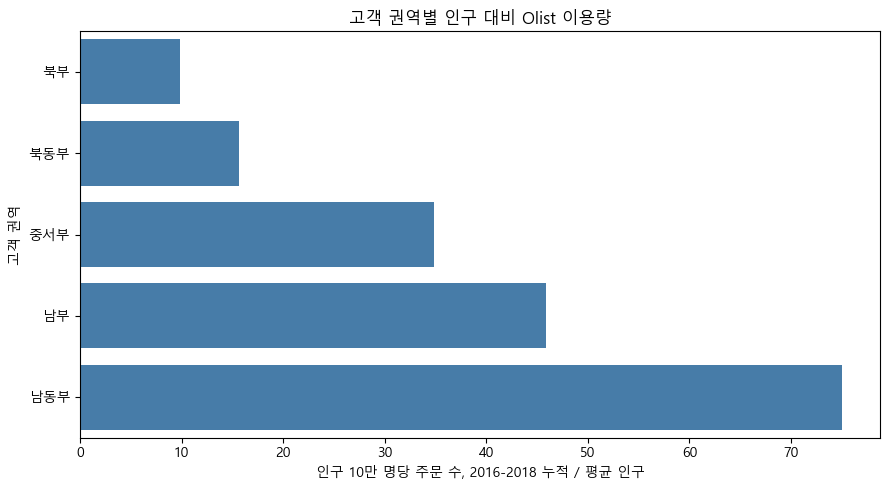

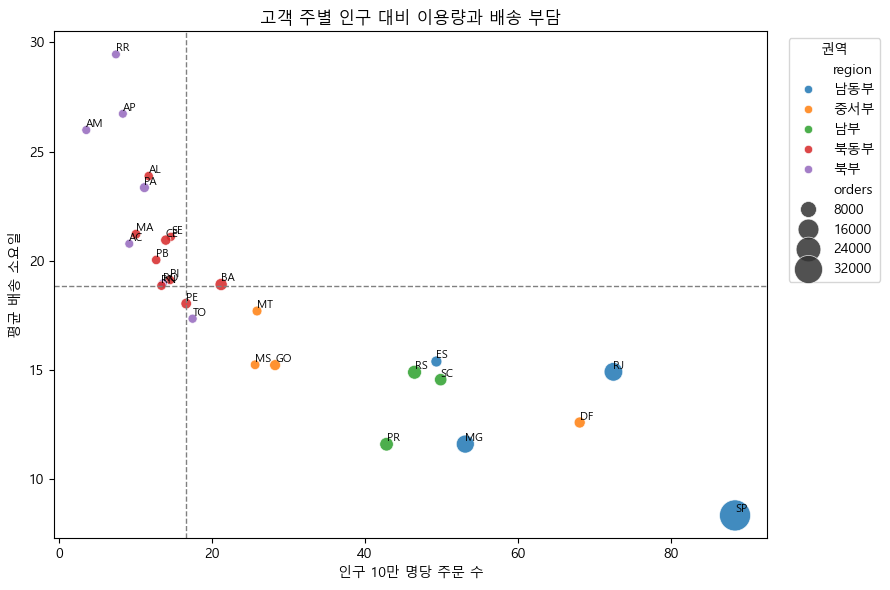

In [8]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=region_usage.sort_values("orders_per_100k"),
    x="orders_per_100k",
    y="region",
    color="#377eb8",
)
plt.title("고객 권역별 인구 대비 Olist 이용량")
plt.xlabel("인구 10만 명당 주문 수, 2016-2018 누적 / 평균 인구")
plt.ylabel("고객 권역")
plt.tight_layout()

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=state_usage,
    x="orders_per_100k",
    y="avg_delivery_days",
    hue="region",
    size="orders",
    sizes=(40, 500),
    alpha=0.85,
)
for _, row in state_usage.iterrows():
    plt.text(row["orders_per_100k"], row["avg_delivery_days"], row["uf"], fontsize=8, ha="left", va="bottom")
plt.axvline(state_usage["orders_per_100k"].median(), color="gray", linestyle="--", linewidth=1)
plt.axhline(state_usage["avg_delivery_days"].median(), color="gray", linestyle="--", linewidth=1)
plt.title("고객 주별 인구 대비 이용량과 배송 부담")
plt.xlabel("인구 10만 명당 주문 수")
plt.ylabel("평균 배송 소요일")
plt.legend(title="권역", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 9. 인프라 투자 후보 점수

투자 후보는 단순히 평점이 낮은 지역이 아니라, **인구 대비 이용량이 낮고 물류 부담이 높은 지역**으로 정의합니다.

점수 구성:

- `under_usage_score`: 인구 대비 주문 수가 낮을수록 높음
- `delivery_burden_score`: 평균 배송일, 예상 배송일 초과, 지연율이 높을수록 높음
- `infra_priority_score`: 이용량 부족 60% + 물류 부담 40%

이 점수는 최적화 모델이 아니라, 인프라 투자 후보를 우선순위로 정렬하기 위한 탐색 지표입니다.

`candidate_group`은 이용량과 물류 부담을 함께 해석하기 위한 분류입니다.

| candidate_group | 조건 | 해석 |
|---|---|---|
| `A_infra_investment_candidate` | 인구 대비 이용량 낮음 + 물류 부담 높음 | 인프라 투자 우선 후보입니다. 현재 이용 침투율이 낮고 배송 부담도 커서, 물류 접근성이 시장 확대의 제약 요인일 가능성이 큽니다. |
| `B_logistics_bottleneck_in_existing_market` | 인구 대비 이용량 높음 + 물류 부담 높음 | 이미 이용량은 있지만 배송 병목이 있는 지역입니다. 신규 인프라보다 배송 처리 효율화, 허브 확충, 라스트마일 개선 관점으로 볼 수 있습니다. |
| `C_market_development_candidate` | 인구 대비 이용량 낮음 + 물류 부담 낮음 | 물류보다는 인지도, 상품 공급, 마케팅, 결제/접근성 문제가 더 클 수 있는 지역입니다. 인프라 단독 투자 우선순위는 낮게 봅니다. |
| `D_mature_or_lower_priority` | 인구 대비 이용량 높음 + 물류 부담 낮음 | 상대적으로 성숙하거나 단기 인프라 투자 필요성이 낮은 지역입니다. 벤치마크 권역으로 활용할 수 있습니다. |

따라서 본 분석에서 가장 주목할 그룹은 `A_infra_investment_candidate`입니다. 이 그룹은 단순히 평점이 낮은 지역이 아니라, **인구 규모 대비 Olist 이용이 충분히 확산되지 않았고 동시에 배송 부담이 높은 지역**입니다.

### `infra_priority_score` 가중치 근거

`infra_priority_score`는 다음과 같이 계산합니다.

```text
infra_priority_score = 0.60 * under_usage_score + 0.40 * delivery_burden_score
```

이 분석의 주 목적은 만족도 개선이 아니라 **인프라 구축을 통해 미충족 시장을 확장할 수 있는 지역을 찾는 것**입니다. 따라서 현재 배송이 불편한 지역을 찾는 것만큼이나, 인구 규모에 비해 Olist 이용이 충분히 침투하지 못한 지역을 찾는 것이 중요합니다. 이 때문에 `under_usage_score`에 더 높은 가중치인 60%를 부여했습니다.

`delivery_burden_score`는 인프라 필요성을 뒷받침하는 보조 축입니다. 배송 소요일, 예상 배송일 초과, 지연율이 높다면 낮은 이용량이 단순한 수요 부족이 아니라 물류 접근성 문제와 연결되어 있을 가능성이 커집니다. 다만 배송 부담만 높고 이미 이용량이 높은 지역은 신규 시장 확장보다 기존 병목 개선에 가깝기 때문에, 전체 점수에서는 40%로 반영했습니다.

정리하면 60:40 가중치는 다음 판단을 반영합니다.

- 60% `under_usage_score`: 인프라 투자의 핵심 목적은 인구 대비 이용량이 낮은 미개척/저침투 지역을 찾는 것
- 40% `delivery_burden_score`: 낮은 이용량이 물류 문제와 연결되어 있는지 확인하는 보조 근거

이 가중치는 비용 자료나 실제 투자 성과로 추정한 최적값은 아닙니다. 따라서 최종 의사결정에서는 50:50, 70:30 같은 민감도 분석을 추가해 후보 지역의 순위가 안정적인지 확인하는 것이 좋습니다.

In [13]:
def minmax(series):
    s = series.astype(float)
    if s.max() == s.min():
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

candidate_df = state_usage.copy()
candidate_df["usage_score"] = minmax(candidate_df["orders_per_100k"])
candidate_df["under_usage_score"] = 1 - candidate_df["usage_score"]
candidate_df["delivery_days_score"] = minmax(candidate_df["avg_delivery_days"])
candidate_df["late_rate_score"] = minmax(candidate_df["late_rate"])
candidate_df["estimated_delay_score"] = minmax(candidate_df["avg_delivery_vs_estimated_days"])
candidate_df["delivery_burden_score"] = (
    0.45 * candidate_df["delivery_days_score"]
    + 0.35 * candidate_df["estimated_delay_score"]
    + 0.20 * candidate_df["late_rate_score"]
)
candidate_df["infra_priority_score"] = (
    0.60 * candidate_df["under_usage_score"]
    + 0.40 * candidate_df["delivery_burden_score"]
)

usage_median = candidate_df["orders_per_100k"].median()
burden_median = candidate_df["delivery_burden_score"].median()

conditions = [
    candidate_df["orders_per_100k"].lt(usage_median) & candidate_df["delivery_burden_score"].ge(burden_median),
    candidate_df["orders_per_100k"].ge(usage_median) & candidate_df["delivery_burden_score"].ge(burden_median),
    candidate_df["orders_per_100k"].lt(usage_median) & candidate_df["delivery_burden_score"].lt(burden_median),
]
choices = [
"A_infra_investment_candidate",
"B_logistics_bottleneck_in_existing_market",
"C_market_development_candidate",
]
candidate_df["candidate_group"] = np.select(conditions, choices, default="D_mature_or_lower_priority")

candidate_df = candidate_df.sort_values("infra_priority_score", ascending=False)
display(candidate_df[
    [
        "uf", "state", "region", "avg_population", "orders", "orders_per_100k",
        "under_usage_score", "delivery_burden_score", "infra_priority_score", "candidate_group",
        "avg_delivery_days", "avg_delivery_vs_estimated_days", "late_rate", "avg_review_score",
    ]
])

,uf,state,region,avg_population,orders,orders_per_100k,under_usage_score,delivery_burden_score,infra_priority_score,candidate_group,avg_delivery_days,avg_delivery_vs_estimated_days,late_rate,avg_review_score
1,AL,Alagoas,북동부,"3,352,535.3333",393,11.7225,0.9038,0.8812,0.8948,A_infra_investment_candidate,23.8779,-8.2409,0.2366,3.8718
9,MA,Maranhão,북동부,"6,996,440.0000",704,10.0623,0.9233,0.7714,0.8626,A_infra_investment_candidate,21.2188,-8.8366,0.2003,3.8362
21,RR,Roraima,북부,"537,811.0000",40,7.4376,0.9543,0.6416,0.8292,A_infra_investment_candidate,29.4500,-16.5043,0.1250,3.8750
24,SE,Sergipe,북동부,"2,277,401.0000",333,14.6219,0.8696,0.7100,0.8058,A_infra_investment_candidate,21.0961,-9.2808,0.1532,3.9066
5,CE,Ceará,북동부,"9,019,924.0000",1259,13.9580,0.8774,0.6870,0.8013,A_infra_investment_candidate,20.9460,-10.0105,0.1557,3.9401
13,PA,Pará,북부,"8,384,283.0000",936,11.1637,0.9104,0.6044,0.7880,A_infra_investment_candidate,23.3494,-13.3769,0.1229,3.9090
16,PI,Piauí,북동부,"3,231,989.3333",469,14.5112,0.8709,0.6393,0.7783,A_infra_investment_candidate,19.1215,-10.5045,0.1620,4.0022
2,AM,Amazonas,북부,"4,048,630.6667",144,3.5568,1.0000,0.4157,0.7663,C_market_development_candidate,25.9861,-18.8690,0.0417,4.2587
14,PB,Paraíba,북동부,"4,007,156.3333",509,12.7023,0.8922,0.5447,0.7532,A_infra_investment_candidate,20.0373,-12.6130,0.1100,4.0734
3,AP,Amapá,북부,"803,170.3333",67,8.3419,0.9436,0.4288,0.7377,C_market_development_candidate,26.7313,-19.0594,0.0448,4.2424


## 10. 기대효과 프레임

인프라 투자 효과는 단순한 리뷰 평점 개선이 아니라 **시장 접근성 확대와 물류 병목 완화**로 제시하는 것이 좋습니다.

- 성숙 권역의 인구 대비 이용량을 벤치마크로 삼는다.
- 저이용 권역이 벤치마크의 일부만 따라가도 추가 주문 잠재량이 얼마나 되는지 추정한다.
- 동시에 해당 지역의 배송 소요 시간과 지연율이 높다면, 인프라 투자가 이용량 확대와 배송 경험 개선을 동시에 노릴 수 있음을 강조한다.
- 이용량이 낮은 지역의 핵심 문제를 단순 수요 부족으로만 보지 않고, 배송 리드타임, 지연 가능성, 운임 부담 같은 물류 접근성 제약으로 해석한다.
- 인프라가 개선되면 배송 가능 지역 확대, 배송일 단축, 예상 배송일 신뢰도 개선, 판매자/고객 네트워크 확대를 통해 장기적으로 주문 침투율을 끌어올릴 수 있다.
- 따라서 기대효과는 `추가 주문 잠재량`, `배송 부담 완화`, `지역 간 서비스 격차 축소` 세 가지 축으로 제시한다.

아래 셀에서는 남부/남동부를 성숙 권역 벤치마크로 보고, 북부/북동부/중서부가 그 수준까지 올라갈 때의 추가 주문 잠재량을 단순 시뮬레이션합니다. 이 값은 정확한 매출 예측이 아니라, 인프라 투자 필요성을 설명하기 위한 **시장 기회 규모의 참고 지표**입니다.

In [10]:
benchmark_regions = ["남부", "남동부"]
target_regions = ["북부", "북동부", "중서부"]

benchmark_orders_per_100k = region_usage.loc[
    region_usage["region"].isin(benchmark_regions), "orders_per_100k"
].mean()

expected_effect = region_usage[region_usage["region"].isin(target_regions)].copy()
expected_effect["benchmark_orders_per_100k"] = benchmark_orders_per_100k
expected_effect["gap_orders_per_100k"] = (
    expected_effect["benchmark_orders_per_100k"] - expected_effect["orders_per_100k"]
).clip(lower=0)
expected_effect["potential_additional_orders"] = (
    expected_effect["gap_orders_per_100k"] * expected_effect["population"] / 100_000
)
expected_effect = expected_effect.sort_values("potential_additional_orders", ascending=False)

display(expected_effect[
    [
        "region", "population", "orders", "orders_per_100k", "benchmark_orders_per_100k",
        "gap_orders_per_100k", "potential_additional_orders", "avg_delivery_days",
        "late_rate", "avg_review_score",
    ]
])

,region,population,orders,orders_per_100k,benchmark_orders_per_100k,gap_orders_per_100k,potential_additional_orders,avg_delivery_days,late_rate,avg_review_score
2,북동부,"56,976,958.3333",8917,15.6502,60.4593,44.8092,"25,530.8934",21.5098,0.1076,4.1807
3,북부,"17,942,079.0000",1776,9.8985,60.4593,50.5608,"9,071.6627",22.6364,0.0666,4.0815
4,중서부,"15,874,260.0000",5529,34.8300,60.4593,25.6294,"4,068.4730",15.4222,0.0527,4.1084


## 11. 결과 저장

In [11]:
state_year_usage.to_csv(OUTPUT_DIR / "population_adjusted_state_year_usage.csv", index=False, encoding="utf-8-sig")
state_usage.to_csv(OUTPUT_DIR / "population_adjusted_state_usage.csv", index=False, encoding="utf-8-sig")
region_year_usage.to_csv(OUTPUT_DIR / "population_adjusted_region_year_usage.csv", index=False, encoding="utf-8-sig")
region_usage.to_csv(OUTPUT_DIR / "population_adjusted_region_usage.csv", index=False, encoding="utf-8-sig")
candidate_df.to_csv(OUTPUT_DIR / "infrastructure_investment_candidates.csv", index=False, encoding="utf-8-sig")
expected_effect.to_csv(OUTPUT_DIR / "infrastructure_expected_effect_by_region.csv", index=False, encoding="utf-8-sig")

print(f"saved outputs to: {OUTPUT_DIR}")

saved outputs to: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs
